# Bài Lab: U-Net với Oxford Pets Dataset (500 ảnh)

## Phần 1: Setup và Tải Dữ Liệu (15 phút)

In [1]:
# === SETUP CƠ BẢN ===
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import os
import glob
from google.colab import drive

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [2]:
# === TẢI DỮ LIỆU ===
# Tải Oxford Pets Dataset
!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

print("Dataset đã được tải xong!")

Dataset đã được tải xong!


In [3]:
# Kiểm tra dữ liệu
IMAGE_PATH = 'images/'
MASK_PATH = 'annotations/trimaps/'

image_files = glob.glob(IMAGE_PATH + '*.jpg')
mask_files = glob.glob(MASK_PATH + '*.png')

print(f"Tổng số ảnh: {len(image_files)}")
print(f"Tổng số mask: {len(mask_files)}")

Tổng số ảnh: 7390
Tổng số mask: 7390


## Phần 2: Tiền Xử Lý Dữ Liệu (15 phút)

In [4]:
# Cấu hình
IMG_HEIGHT = 128
IMG_WIDTH = 128
MAX_SAMPLES = 500  # Giới hạn 500 ảnh

def preprocess_data(image_path, mask_path, img_size=(IMG_HEIGHT, IMG_WIDTH)):
    """Tiền xử lý ảnh và mask"""
    try:
        # Đọc ảnh
        image = cv2.imread(image_path)
        if image is None:
            return None, None
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, img_size)
        image = image.astype(np.float32) / 255.0
         # Đọc mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None, None
        mask = cv2.resize(mask, img_size)

        # Chuyển trimap thành binary mask (1=pet, 0=background)
        binary_mask = (mask == 1).astype(np.float32)

        return image, binary_mask
    except:
        return None, None

In [5]:
def create_limited_dataset(image_files, max_samples=500):
    """Tạo dataset với số lượng giới hạn"""
    images = []
    masks = []

    count = 0
    processed = 0

    print("Đang xử lý dữ liệu...")

    for img_path in image_files:
        if count >= max_samples:
            break

        # Tìm mask tương ứng
        img_name = os.path.basename(img_path).replace('.jpg', '')
        mask_path = f"{MASK_PATH}{img_name}.png"

        if os.path.exists(mask_path):
            img, mask = preprocess_data(img_path, mask_path)

            if img is not None and mask is not None:
                images.append(img)
                masks.append(mask)
                count += 1

                # Progress
                if count % 50 == 0:
                    print(f"Đã xử lý: {count}/{max_samples}")

        processed += 1
        if processed > max_samples * 2:  # Tránh vòng lặp vô hạn
            break

    return np.array(images), np.array(masks)

Đang xử lý dữ liệu...
Đã xử lý: 50/500
Đã xử lý: 100/500
Đã xử lý: 150/500
Đã xử lý: 200/500
Đã xử lý: 250/500
Đã xử lý: 300/500
Đã xử lý: 350/500
Đã xử lý: 400/500
Đã xử lý: 450/500
Đã xử lý: 500/500
Dataset final shape: X=(500, 128, 128, 3), y=(500, 128, 128)


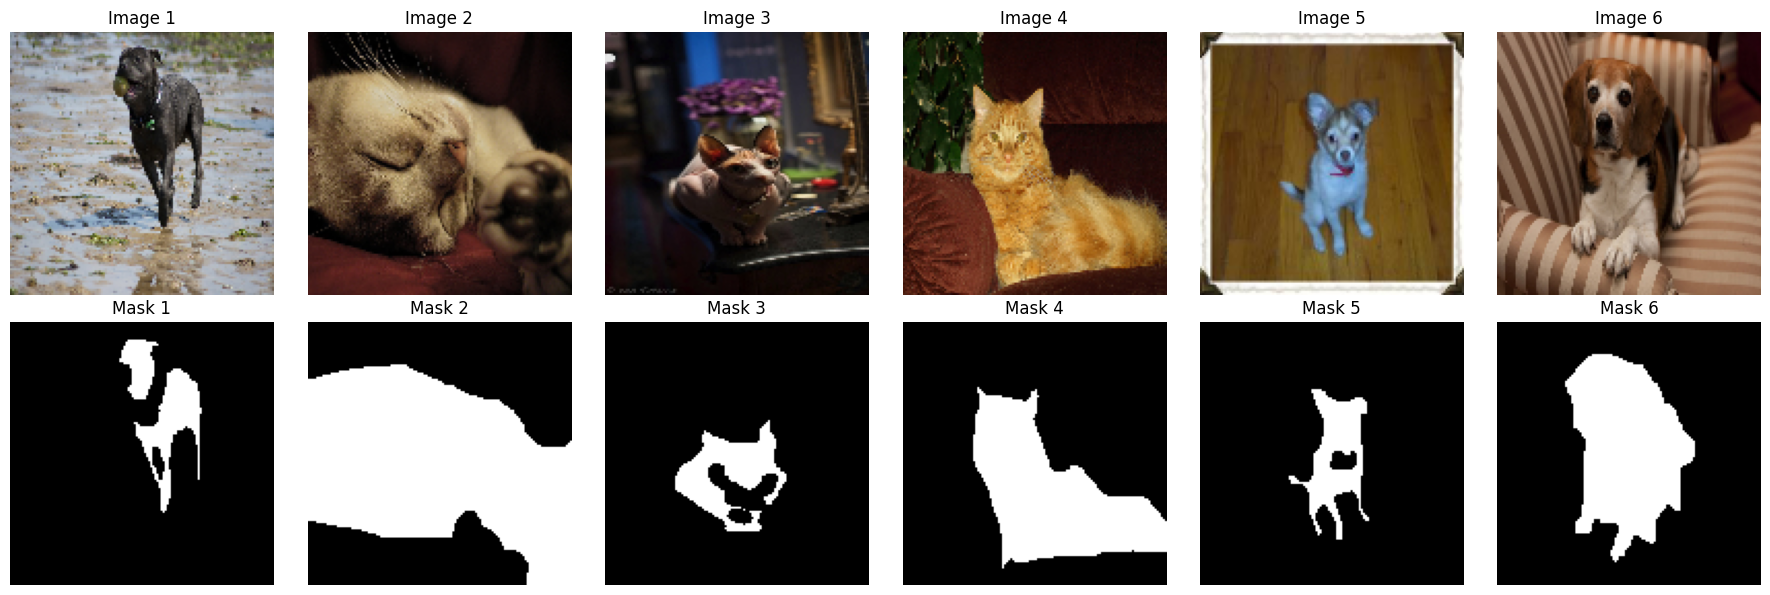

In [6]:
# Tạo dataset
X, y = create_limited_dataset(image_files, MAX_SAMPLES)
print(f"Dataset final shape: X={X.shape}, y={y.shape}")

# Hiển thị mẫu
def display_samples(X, y, num_samples=6):
    fig, axes = plt.subplots(2, num_samples, figsize=(18, 6))

    for i in range(num_samples):
        # Ảnh gốc
        axes[0, i].imshow(X[i])
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')

        # Mask
        axes[1, i].imshow(y[i], cmap='gray')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

display_samples(X, y)

## Phần 3: Xây Dựng U-Net Nhỏ Gọn (15 phút)

In [7]:
def compact_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    """U-Net nhỏ gọn cho training nhanh"""
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D(2)(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D(2)(c3)

    # Bottleneck
    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = Conv2DTranspose(128, 2, strides=2, padding='same')(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)

    u6 = Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(32, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)

    # Output
    outputs = Conv2D(1, 1, activation='sigmoid')(c7)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [8]:
# Tạo model
model = compact_unet()
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Model parameters: {model.count_params():,}")
print("Model đã sẵn sàng để training!")

Model parameters: 1,925,601
Model đã sẵn sàng để training!


## Phần 4: Training (20 phút)

In [9]:
# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Expand dimensions cho mask
y_train = np.expand_dims(y_train, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, monitor='val_loss')
]

# Training
print("Bắt đầu training...")
history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=20,  # Có thể dừng sớm với EarlyStopping
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("Training hoàn thành!")

Train: (400, 128, 128, 3), Test: (100, 128, 128, 3)
Bắt đầu training...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 239ms/step - accuracy: 0.6750 - loss: 0.6394 - val_accuracy: 0.7112 - val_loss: 0.5989 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6959 - loss: 0.5946 - val_accuracy: 0.7112 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.6959 - loss: 0.6027 - val_accuracy: 0.7112 - val_loss: 0.5946 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6959 - loss: 0.5629 - val_accuracy: 0.7112 - val_loss: 0.5003 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7232 - loss: 0.4974 - val_accuracy: 0.7797 - val_loss: 0.4575 - learning_rate: 0.0010
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7657 - loss: 0.4855 - val_accuracy: 0.7737 - val_loss: 0.4705 - learning_rate: 0.0010
Epoch 7/20
25/25 ━━━

## Phần 5: Đánh Giá và Visualization (15 phút)

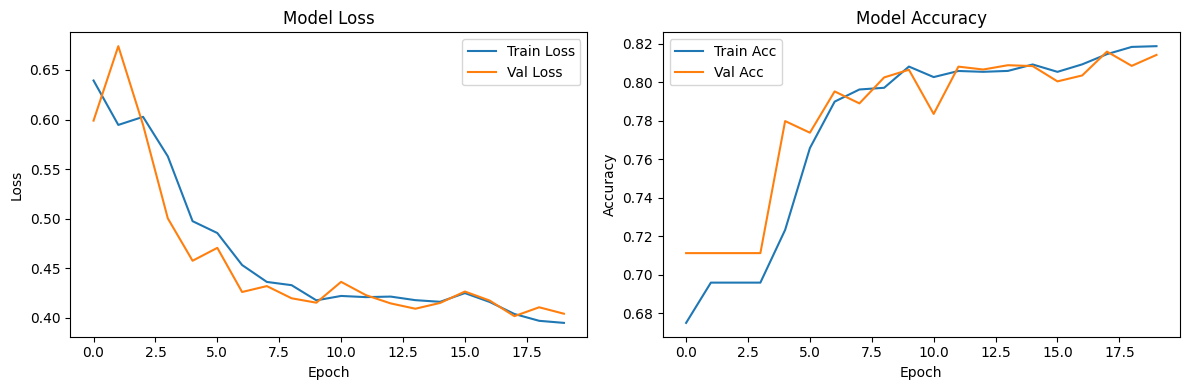

In [10]:
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


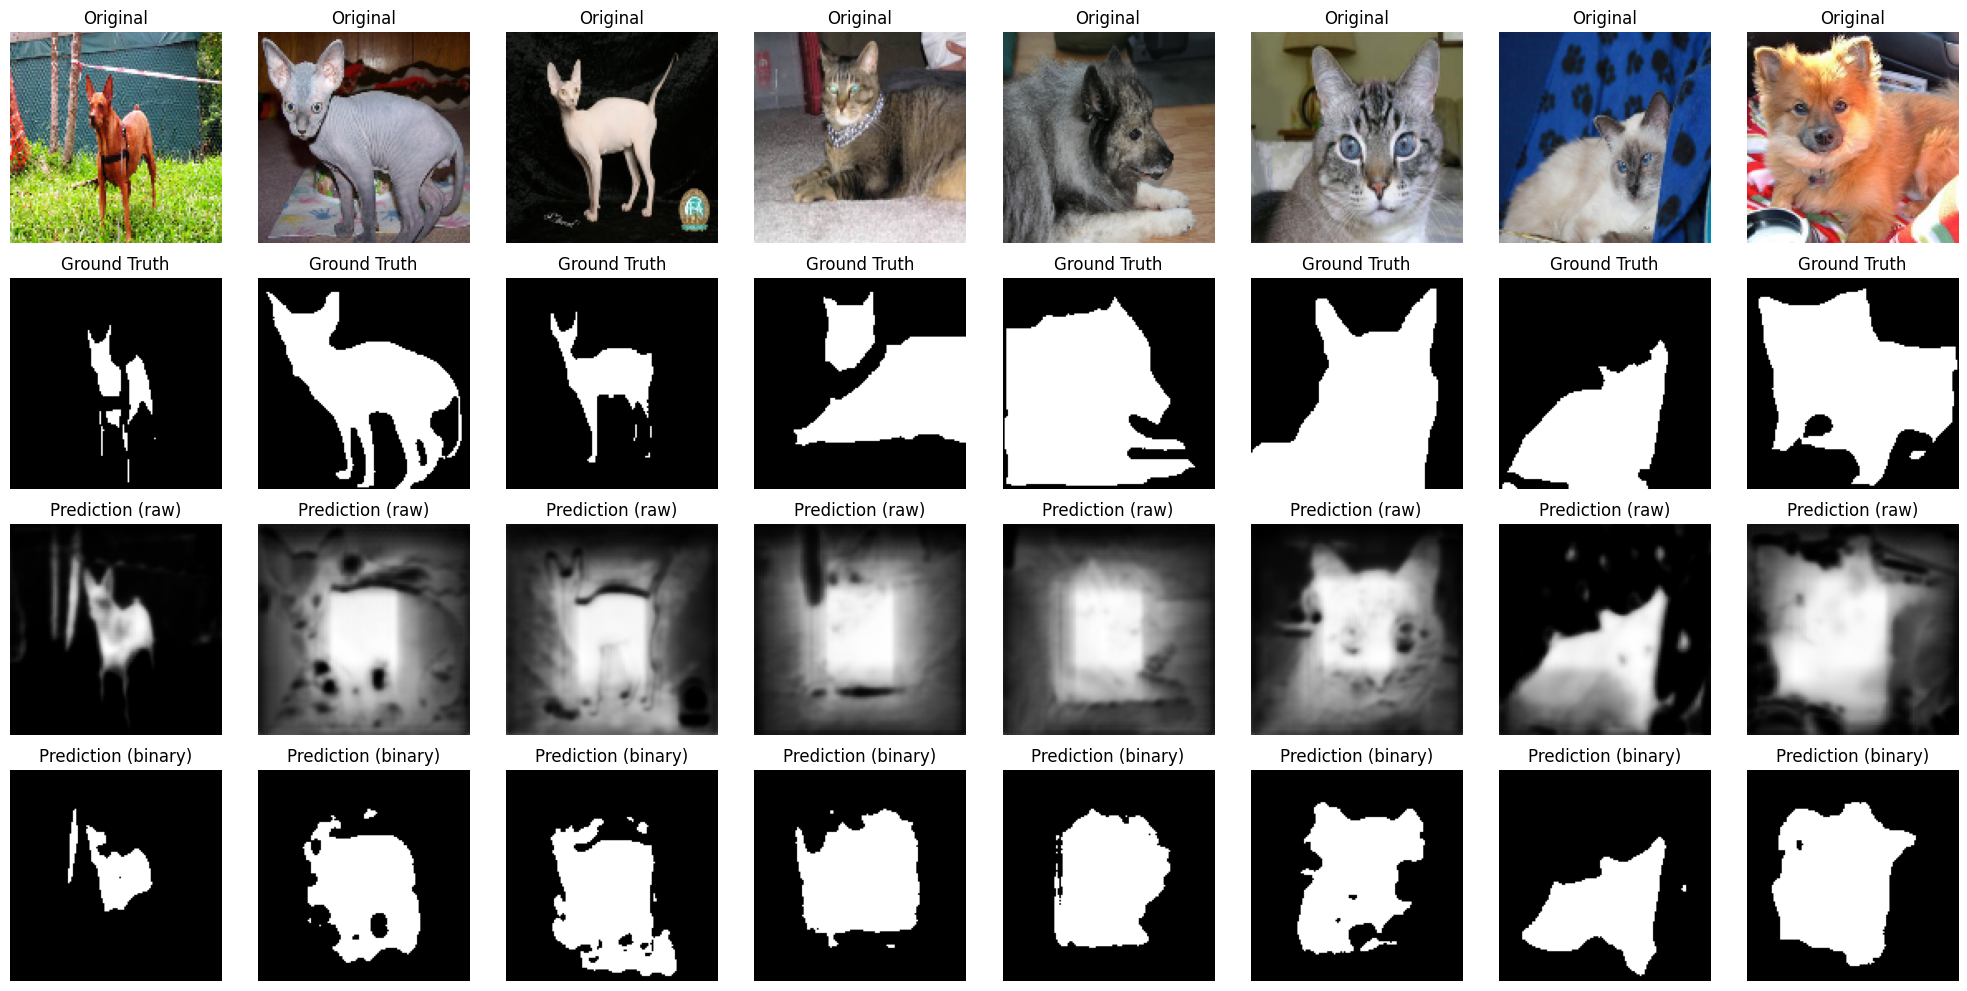

In [11]:
# Predict và hiển thị kết quả
def show_predictions(model, X_test, y_test, num_samples=8):
    predictions = model.predict(X_test[:num_samples])

    fig, axes = plt.subplots(4, num_samples, figsize=(20, 10))

    for i in range(num_samples):
        # Ảnh gốc
        axes[0, i].imshow(X_test[i])
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        # Ground truth
        axes[1, i].imshow(y_test[i].squeeze(), cmap='gray')
        axes[1, i].set_title('Ground Truth')
        axes[1, i].axis('off')

        # Prediction (raw)
        pred_raw = predictions[i].squeeze()
        axes[2, i].imshow(pred_raw, cmap='gray')
        axes[2, i].set_title('Prediction (raw)')
        axes[2, i].axis('off')

        # Prediction (binary)
        pred_binary = (pred_raw > 0.5).astype(np.float32)
        axes[3, i].imshow(pred_binary, cmap='gray')
        axes[3, i].set_title('Prediction (binary)')
        axes[3, i].axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test)

In [12]:
# Tính IoU
def calculate_iou(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred > threshold).astype(np.float32)

    intersection = np.sum(y_true * y_pred_binary, axis=(1, 2))
    union = np.sum(y_true, axis=(1, 2)) + np.sum(y_pred_binary, axis=(1, 2)) - intersection

    iou = intersection / (union + 1e-7)
    return np.mean(iou)

# Đánh giá
test_predictions = model.predict(X_test)
iou_score = calculate_iou(y_test.squeeze(), test_predictions.squeeze())
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]

print(f"IoU Score: {iou_score:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step
IoU Score: 0.5012
Test Accuracy: 0.8158


## Phần 6: Bài Tập Thực Hành (10 phút)

In [15]:
# ===== BÀI TẬP 1: Thử nghiệm threshold =====
print("Bài tập 1: Thử nghiệm threshold khác nhau")
thresholds = [0.3, 0.5, 0.7, 0.9]
for thresh in thresholds:
  iou = calculate_iou(y_test.squeeze(), test_predictions.squeeze(), thresh)
  print(f"Threshold {thresh}: IoU = {iou:.4f}")

Bài tập 1: Thử nghiệm threshold khác nhau
Threshold 0.3: IoU = 0.5058
Threshold 0.5: IoU = 0.5012
Threshold 0.7: IoU = 0.3973
Threshold 0.9: IoU = 0.0098


In [18]:
# ===== BÀI TẬP 2: So sánh model nhỏ hơn =====
print("\nBài tập 2: So sánh với model nhỏ hơn")

def mini_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    """U-Net rất nhỏ"""
    inputs = Input(input_shape)
    # Encoder
    c1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling2D(2)(c2)

    # Bottleneck
    c3 = Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u4 = Conv2DTranspose(32, 2, strides=2, padding='same')(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(32, 3, activation='relu', padding='same')(u4)

    u5 = Conv2DTranspose(16, 2, strides=2, padding='same')(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(16, 3, activation='relu', padding='same')(u5)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs=[inputs], outputs=[outputs])

# Train mini_unet và so sánh
mini_model = mini_unet()
print(f"Mini model parameters: {mini_model.count_params():,}")
print(f"So với model chính: {model.count_params():,}")


Bài tập 2: So sánh với model nhỏ hơn
Mini model parameters: 56,977
So với model chính: 1,925,601


In [17]:
# ===== BÀI TẬP 3: Phân tích lỗi =====
print("\nBài tập 3: Phân tích các trường hợp dự đoán sai")

# Tìm các mẫu có IoU thấp
individual_ious = []
for i in range(len(y_test)):
   # Calculate IoU for each sample
    iou = calculate_iou(y_test[i], test_predictions[i])
    individual_ious.append(iou)

# Sắp xếp theo IoU
sorted_indices = np.argsort(individual_ious)
worst_cases = sorted_indices[:4]
# 4 trường hợp tệ nhất
best_cases = sorted_indices[-4:]
# 4 trường hợp tốt nhất

print("4 trường hợp dự đoán tệ nhất:")
for i in worst_cases:
   print(f"Sample {i}: IoU = {individual_ious[i]:.4f}")

print("\n4 trường hợp dự đoán tốt nhất:")
for i in best_cases:
   print(f"Sample {i}: IoU = {individual_ious[i]:.4f}")


Bài tập 3: Phân tích các trường hợp dự đoán sai
4 trường hợp dự đoán tệ nhất:
Sample 62: IoU = 0.0000
Sample 56: IoU = 0.0000
Sample 26: IoU = 0.0146
Sample 65: IoU = 0.0207

4 trường hợp dự đoán tốt nhất:
Sample 71: IoU = 0.6147
Sample 29: IoU = 0.6228
Sample 86: IoU = 0.6259
Sample 53: IoU = 0.6607
